# Federated FedAvg + LoRA over 4 FlowerTune domains (extreme non-IID)

Prototype for **"Rethinking Non-IID Challenges in Federated LLMs."**

One client per domain (medical / finance / coding / general) → maximal non-IID. Manual FedAvg loop with LoRA adapters (structure maps 1:1 onto Flower later). Logs per-domain held-out loss/perplexity, client drift, pairwise update cosine (overall + A-only + B-only), gradient-conflict fraction, and global-model movement, then plots them.

**Before running:** in Kaggle notebook settings enable **Internet: On** and **GPU: On** (T4 or P100). No HF token needed — Qwen2.5 is ungated.

> **LoRA FedAvg note:** we average `A` and `B` state dicts independently (the FedIT approach). This is *not* identical to averaging the product `B@A`; it's the correct **baseline** to start from. Aggregation refinements (FLoRA / LoRA-FAIR) come later.

## 1 · Install deps
Kaggle already has `torch`; the rest are light. We also **remove Kaggle's preinstalled `torchao 0.10`**, which otherwise crashes PEFT's LoRA setup. If you hit the torchao error mid-session, run this cell then **Run → Restart** and Run All.

In [1]:
import subprocess, sys
def _pip(*args):
    # no check=True on uninstall: pip may return nonzero if a pkg is absent
    subprocess.run([sys.executable, "-m", "pip", *args])

_pip("install", "-q", "transformers>=4.44", "peft>=0.12", "datasets>=2.20", "accelerate>=0.33")

# Kaggle preinstalls torchao 0.10, which is below what PEFT's LoRA dispatch requires;
# it raises ImportError inside get_peft_model. We don't use torchao (no quantization) -> remove it.
_pip("uninstall", "-y", "torchao")
print("\nIf torchao was already imported this session, do Run -> Restart, then Run All.")


If torchao was already imported this session, do Run -> Restart, then Run All.


## 2 · Imports

In [2]:
import os, math, copy, random, itertools, warnings
from dataclasses import dataclass, field
from typing import List, Dict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import (
    LoraConfig, get_peft_model,
    get_peft_model_state_dict, set_peft_model_state_dict,
)

warnings.filterwarnings("ignore")

## 3 · Config
Everything you'd tweak lives here. To swap the model, change `model_id` (e.g. `HuggingFaceTB/SmolLM2-360M-Instruct` for faster, `meta-llama/Llama-3.2-1B-Instruct` for stronger — the latter needs HF auth).

**Verify the four `clients` repo ids resolve on HF** — the finance/code namespaces have mirrors.

In [3]:
@dataclass
class Config:
    model_id: str = "Qwen/Qwen2.5-0.5B-Instruct"
    seed: int = 42

    # (domain_name, hf_repo_id) -- VERIFY these resolve on HF
    clients: List[tuple] = field(default_factory=lambda: [
        ("general", "vicgalle/alpaca-gpt4"),
        ("finance", "FinGPT/fingpt-sentiment-train"),
        ("medical", "medalpaca/medical_meadow_medical_flashcards"),
        ("coding",  "sahil2801/CodeAlpaca-20k"),
    ])

    # federated schedule (modest for a Kaggle session; scale up later)
    num_rounds: int = 8
    local_steps: int = 40
    batch_size: int = 4
    eval_batch_size: int = 8
    lr: float = 2e-4
    max_len: int = 512

    # data subsampling for speed
    train_per_client: int = 1000
    eval_per_client: int = 200

    # LoRA (q,v = light & fast; add k/o/mlp for a richer drift signal)
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    lora_targets: List[str] = field(default_factory=lambda: ["q_proj", "v_proj"])

    weighted_fedavg: bool = True
    out_dir: str = "/kaggle/working"

cfg = Config()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(cfg.out_dir, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(cfg.seed)
print("device:", DEVICE)

device: cuda


## 4 · Model + tokenizer
Load the base SLM, wrap it in a LoRA adapter, and record the (sorted) LoRA parameter keys used for stable flattening in drift/cosine metrics.

In [4]:
print(f"Loading {cfg.model_id} ...")
tokenizer = AutoTokenizer.from_pretrained(cfg.model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    cfg.model_id,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
lora_cfg = LoraConfig(
    r=cfg.lora_r, lora_alpha=cfg.lora_alpha, lora_dropout=cfg.lora_dropout,
    target_modules=cfg.lora_targets, task_type="CAUSAL_LM", bias="none",
)
model = get_peft_model(base_model, lora_cfg).to(DEVICE)
model.print_trainable_parameters()

GLOBAL_KEYS = sorted(get_peft_model_state_dict(model).keys())
KEYS_A = [k for k in GLOBAL_KEYS if "lora_A" in k]
KEYS_B = [k for k in GLOBAL_KEYS if "lora_B" in k]

Loading Qwen/Qwen2.5-0.5B-Instruct ...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


## 5 · Data
Format each alpaca-style dataset into a chat template and **mask the prompt tokens** so loss is computed on the *response only* — this makes per-domain perplexity a meaningful quantity.

In [5]:
def _get(ex, *names):
    for n in names:
        v = ex[n] if n in ex else None
        if v is not None and str(v).strip():
            return str(v).strip()
    return ""

def build_example(ex, stats=None):
    """Mask by CONSTRUCTION: tokenize prompt + response separately, then concat.
    (Avoids fragile prefix-matching between two apply_chat_template calls.)"""
    instr = _get(ex, "instruction", "question", "prompt", "Question")
    inp   = _get(ex, "input", "context")
    out   = _get(ex, "output", "answer", "response", "completion", "text")
    if not out:
        if stats is not None: stats["no_output"] += 1
        return None
    user = instr if not inp else f"{instr}\n\n{inp}"
    if not user:
        if stats is not None: stats["no_user"] += 1
        return None
    try:
        prompt_text = tokenizer.apply_chat_template(
            [{"role": "user", "content": user}],
            tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt_text = f"### Instruction:\n{user}\n\n### Response:\n"
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
    resp_ids   = tokenizer(out, add_special_tokens=False)["input_ids"] + [tokenizer.eos_token_id]
    input_ids = (prompt_ids + resp_ids)[:cfg.max_len]
    labels    = ([-100] * len(prompt_ids) + resp_ids)[:cfg.max_len]
    if all(t == -100 for t in labels):
        if stats is not None: stats["truncated"] += 1
        return None
    return {"input_ids": input_ids, "labels": labels}

def load_client(domain, repo, n_train, n_eval):
    ds = load_dataset(repo, split="train").shuffle(seed=cfg.seed)
    ds = ds.select(range(min(len(ds), n_train + n_eval)))
    stats = {"no_output": 0, "no_user": 0, "truncated": 0}
    rows = [b for ex in ds if (b := build_example(ex, stats))]
    if not rows:   # diagnostic if something still filters everything out
        print(f"  [{domain}] 0 usable! columns={ds.column_names} skips={stats}")
        print(f"    sample: {{ {', '.join(f'{k!r}: {str(ds[0][k])[:50]!r}' for k in ds.column_names)} }}")
    random.shuffle(rows)
    train, ev = rows[:n_train], rows[n_train:n_train + n_eval]
    print(f"  [{domain:8s}] {repo:45s} train={len(train)} eval={len(ev)}")
    return {"domain": domain, "train": train, "eval": ev}

print("Loading + formatting client datasets ...")
CLIENTS = [load_client(d, r, cfg.train_per_client, cfg.eval_per_client)
           for d, r in cfg.clients]

Loading + formatting client datasets ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-6ef3991c06080e(…):   0%|          | 0.00/48.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

  [general ] vicgalle/alpaca-gpt4                          train=1000 eval=200


...

  [medical ] medalpaca/medical_meadow_medical_flashcards   train=1000 eval=184


README.md:   0%|          | 0.00/147 [00:00<?, ?B/s]

code_alpaca_20k.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/20022 [00:00<?, ? examples/s]

  [coding  ] sahil2801/CodeAlpaca-20k                      train=1000 eval=200


### Batching

In [6]:
def collate(batch):
    maxlen = max(len(b["input_ids"]) for b in batch)
    pad = tokenizer.pad_token_id
    ids, lbl, att = [], [], []
    for b in batch:
        p = maxlen - len(b["input_ids"])
        ids.append(b["input_ids"] + [pad] * p)
        lbl.append(b["labels"]    + [-100] * p)
        att.append([1] * len(b["input_ids"]) + [0] * p)
    return torch.tensor(ids), torch.tensor(lbl), torch.tensor(att)

def batches(data, bs, shuffle=True):
    idx = list(range(len(data)))
    if shuffle: random.shuffle(idx)
    for i in range(0, len(idx), bs):
        yield collate([data[j] for j in idx[i:i + bs]])

## 6 · Federated helpers
Get/set the global LoRA state, flatten for metrics, aggregate (FedAvg), one client's local training, and per-domain evaluation.

In [7]:
def get_global():
    return {k: v.detach().cpu().clone() for k, v in get_peft_model_state_dict(model).items()}

def set_global(sd):
    set_peft_model_state_dict(model, {k: v.to(DEVICE) for k, v in sd.items()})

def flatten(sd, keys):
    return torch.cat([sd[k].flatten().float() for k in keys])

def fedavg(states, weights):
    w = torch.tensor(weights, dtype=torch.float32); w = w / w.sum()
    return {k: sum(states[i][k].float() * w[i] for i in range(len(states))).to(states[0][k].dtype)
            for k in GLOBAL_KEYS}

def local_train(global_sd, data, steps, lr):
    set_global(global_sd)
    model.train()
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    it = itertools.cycle(batches(data, cfg.batch_size))
    running = 0.0
    for _ in range(steps):
        ids, lbl, att = next(it)
        ids, lbl, att = ids.to(DEVICE), lbl.to(DEVICE), att.to(DEVICE)
        out = model(input_ids=ids, attention_mask=att, labels=lbl)
        opt.zero_grad(); out.loss.backward(); opt.step()
        running += out.loss.item()
    return get_global(), running / steps

@torch.no_grad()
def evaluate(state_sd, data):
    set_global(state_sd)
    model.eval()
    tot_loss, tot_tok = 0.0, 0
    for ids, lbl, att in batches(data, cfg.eval_batch_size, shuffle=False):
        ids, lbl, att = ids.to(DEVICE), lbl.to(DEVICE), att.to(DEVICE)
        out = model(input_ids=ids, attention_mask=att, labels=lbl)
        ntok = (lbl != -100).sum().item()
        tot_loss += out.loss.item() * ntok; tot_tok += ntok
    loss = tot_loss / max(tot_tok, 1)
    return loss, math.exp(min(loss, 20))

## 7 · FedAvg training loop
This is the block that becomes a Flower `Strategy`. Each round: every client trains from the same global model, we measure drift + update alignment, aggregate, then evaluate the new global model per domain.

In [8]:
global_sd = get_global()
log = []

for rnd in range(1, cfg.num_rounds + 1):
    round_row = {"round": rnd}
    local_states, weights, update_vecs = [], [], []

    # clients train locally on the SAME global model
    for c in CLIENTS:
        local_sd, tr_loss = local_train(global_sd, c["train"], cfg.local_steps, cfg.lr)
        local_states.append(local_sd)
        weights.append(len(c["train"]) if cfg.weighted_fedavg else 1)
        upd = flatten(local_sd, GLOBAL_KEYS) - flatten(global_sd, GLOBAL_KEYS)
        update_vecs.append(upd)
        round_row[f"trainloss_{c['domain']}"] = tr_loss
        round_row[f"drift_{c['domain']}"]     = upd.norm().item()
        round_row[f"updnorm_{c['domain']}"]   = upd.norm().item()

    # pairwise cosine of client updates: overall + A-only + B-only
    def upd_restricted(local_sd, keys):
        return flatten(local_sd, keys) - flatten(global_sd, keys)
    cos_all, cos_A, cos_B, neg_pairs, npairs = [], [], [], 0, 0
    for i, j in itertools.combinations(range(len(CLIENTS)), 2):
        cij = F.cosine_similarity(update_vecs[i][None], update_vecs[j][None]).item()
        aij = F.cosine_similarity(upd_restricted(local_states[i], KEYS_A)[None],
                                  upd_restricted(local_states[j], KEYS_A)[None]).item()
        bij = F.cosine_similarity(upd_restricted(local_states[i], KEYS_B)[None],
                                  upd_restricted(local_states[j], KEYS_B)[None]).item()
        cos_all.append(cij); cos_A.append(aij); cos_B.append(bij)
        npairs += 1; neg_pairs += int(cij < 0)
        round_row[f"cos_{CLIENTS[i]['domain']}_{CLIENTS[j]['domain']}"] = cij
    round_row["mean_pairwise_cos"]   = float(np.mean(cos_all))
    round_row["mean_pairwise_cos_A"] = float(np.mean(cos_A))
    round_row["mean_pairwise_cos_B"] = float(np.mean(cos_B))
    round_row["grad_conflict_frac"]  = neg_pairs / npairs

    # aggregate (FedAvg) + how far the global model moved
    new_global = fedavg(local_states, weights)
    round_row["global_move"] = (flatten(new_global, GLOBAL_KEYS)
                                - flatten(global_sd, GLOBAL_KEYS)).norm().item()

    # per-domain held-out eval on the NEW global model
    for c in CLIENTS:
        l, ppl = evaluate(new_global, c["eval"])
        round_row[f"evalloss_{c['domain']}"] = l
        round_row[f"ppl_{c['domain']}"]      = ppl
    dom_losses = [round_row[f"evalloss_{c['domain']}"] for c in CLIENTS]
    round_row["evalloss_mean"]  = float(np.mean(dom_losses))
    round_row["evalloss_worst"] = float(np.max(dom_losses))

    global_sd = new_global
    log.append(round_row)
    print(f"round {rnd:2d} | eval(mean)={round_row['evalloss_mean']:.3f} "
          f"worst={round_row['evalloss_worst']:.3f} | "
          f"cos={round_row['mean_pairwise_cos']:+.3f} "
          f"conflict={round_row['grad_conflict_frac']:.2f} "
          f"move={round_row['global_move']:.3f}")

round  1 | eval(mean)=0.897 worst=1.391 | cos=+0.068 conflict=0.00 move=0.858
round  2 | eval(mean)=0.878 worst=1.391 | cos=+0.009 conflict=0.17 move=0.751
round  3 | eval(mean)=0.871 worst=1.392 | cos=-0.009 conflict=0.83 move=0.699
round  4 | eval(mean)=0.865 worst=1.392 | cos=-0.010 conflict=1.00 move=0.694
round  5 | eval(mean)=0.862 worst=1.391 | cos=-0.009 conflict=1.00 move=0.692
round  6 | eval(mean)=0.857 worst=1.390 | cos=-0.011 conflict=1.00 move=0.697
round  7 | eval(mean)=0.856 worst=1.389 | cos=-0.006 conflict=1.00 move=0.686
round  8 | eval(mean)=0.853 worst=1.389 | cos=-0.010 conflict=0.83 move=0.679


## 8 · Save metrics

In [9]:
df = pd.DataFrame(log)
csv_path = os.path.join(cfg.out_dir, "fed_metrics.csv")
df.to_csv(csv_path, index=False)
print("saved:", csv_path)
df

saved: /kaggle/working/fed_metrics.csv


,round,trainloss_general,drift_general,updnorm_general,trainloss_finance,drift_finance,updnorm_finance,trainloss_medical,drift_medical,updnorm_medical,...,evalloss_general,ppl_general,evalloss_finance,ppl_finance,evalloss_medical,ppl_medical,evalloss_coding,ppl_coding,evalloss_mean,evalloss_worst
0,1,1.319497,1.511486,1.511486,0.569380,1.406473,1.406473,1.069943,1.603080,1.603080,...,1.390976,4.018771,0.443263,1.557783,1.120931,3.067710,0.632556,1.882415,0.896932,1.390976
1,2,1.272593,1.515708,1.515708,0.423983,1.331592,1.331592,1.051995,1.556790,1.556790,...,1.390507,4.016886,0.386040,1.471144,1.113344,3.044522,0.623250,1.864980,0.878285,1.390507
2,3,1.370846,1.472715,1.472715,0.410817,1.188276,1.188276,1.063040,1.521996,1.521996,...,1.391573,4.021172,0.368631,1.445754,1.104003,3.016216,0.617837,1.854911,0.870511,1.391573
3,4,1.316352,1.506288,1.506288,0.362789,1.181909,1.181909,1.120498,1.446066,1.446066,...,1.391767,4.021950,0.349894,1.418916,1.102263,3.010973,0.615892,1.851306,0.864954,1.391767
4,5,1.318507,1.471667,1.471667,0.455477,1.263530,1.263530,1.136903,1.437136,1.437136,...,1.390595,4.017240,0.343001,1.409170,1.098942,3.000988,0.615280,1.850174,0.861954,1.390595
5,6,1.382736,1.530868,1.530868,0.413112,1.191519,1.191519,1.055314,1.475689,1.475689,...,1.390109,4.015286,0.329713,1.390569,1.093432,2.984498,0.614763,1.849219,0.857004,1.390109
6,7,1.251155,1.448296,1.448296,0.332520,1.235348,1.235348,1.056810,1.423000,1.423000,...,1.388917,4.010506,0.330247,1.391312,1.087187,2.965918,0.615717,1.850983,0.855517,1.388917
7,8,1.261092,1.489442,1.489442,0.371319,1.153612,1.153612,1.037411,1.396587,1.396587,...,1.389493,4.012816,0.319066,1.375842,1.088468,2.969720,0.614924,1.849516,0.852988,1.389493


## 9 · Visualizations
The key plot is **update alignment** (cell below): if the symmetry hypothesis holds, mean pairwise cosine stays positive and high across the four domains, and the conflict fraction stays near zero.

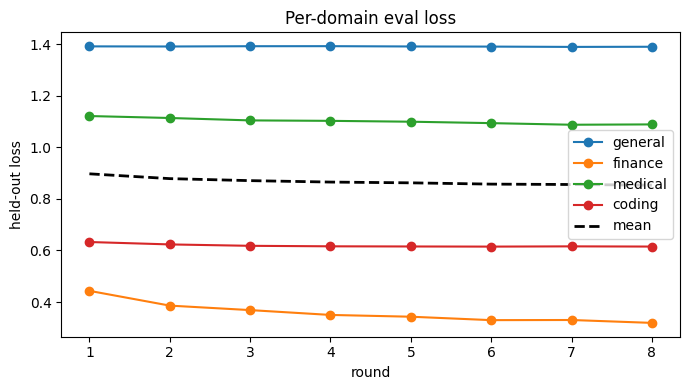

In [10]:
domains = [c["domain"] for c in CLIENTS]

# per-domain eval loss over rounds (+ mean) -> forgetting / negative transfer
plt.figure(figsize=(7, 4))
for d in domains:
    plt.plot(df["round"], df[f"evalloss_{d}"], marker="o", label=d)
plt.plot(df["round"], df["evalloss_mean"], "k--", lw=2, label="mean")
plt.xlabel("round"); plt.ylabel("held-out loss"); plt.title("Per-domain eval loss")
plt.legend(); plt.tight_layout()
plt.savefig(f"{cfg.out_dir}/plot_eval_loss.png", dpi=130); plt.show()

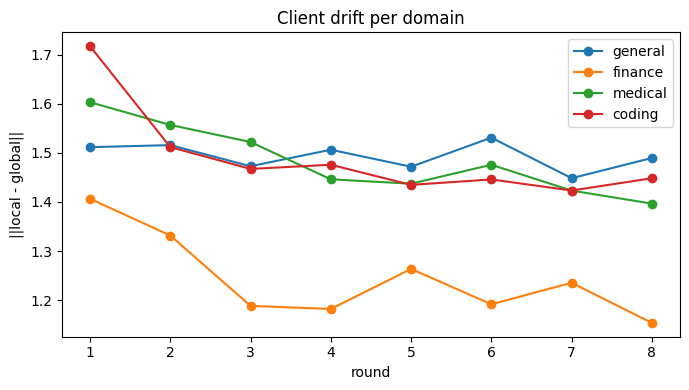

In [11]:
# client drift norm over rounds
plt.figure(figsize=(7, 4))
for d in domains:
    plt.plot(df["round"], df[f"drift_{d}"], marker="o", label=d)
plt.xlabel("round"); plt.ylabel("||local - global||"); plt.title("Client drift per domain")
plt.legend(); plt.tight_layout()
plt.savefig(f"{cfg.out_dir}/plot_drift.png", dpi=130); plt.show()

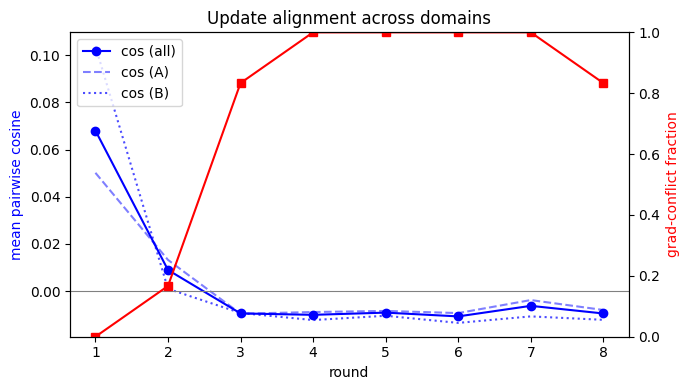

In [12]:
# mean pairwise cosine + gradient-conflict fraction  (THE symmetry-hypothesis plot)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df["round"], df["mean_pairwise_cos"],   "b-o", label="cos (all)")
ax1.plot(df["round"], df["mean_pairwise_cos_A"], "b--", alpha=.5, label="cos (A)")
ax1.plot(df["round"], df["mean_pairwise_cos_B"], "b:",  alpha=.7, label="cos (B)")
ax1.axhline(0, color="grey", lw=.8)
ax1.set_xlabel("round"); ax1.set_ylabel("mean pairwise cosine", color="b"); ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(df["round"], df["grad_conflict_frac"], "r-s", label="conflict frac")
ax2.set_ylabel("grad-conflict fraction", color="r"); ax2.set_ylim(0, 1)
plt.title("Update alignment across domains")
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/plot_alignment.png", dpi=130); plt.show()

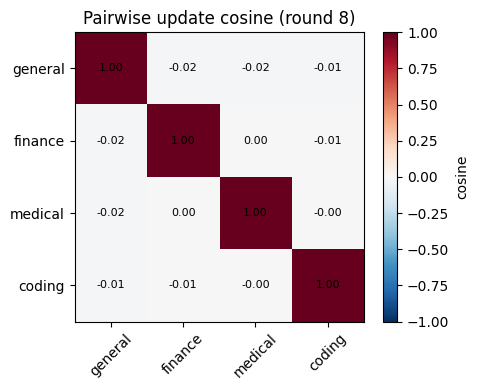

Done. Figures + fed_metrics.csv are in /kaggle/working


In [13]:
# final-round pairwise cosine heatmap
last = df.iloc[-1]
M = np.eye(len(domains))
for i, j in itertools.combinations(range(len(domains)), 2):
    M[i, j] = M[j, i] = last[f"cos_{domains[i]}_{domains[j]}"]
plt.figure(figsize=(5, 4))
plt.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r"); plt.colorbar(label="cosine")
plt.xticks(range(len(domains)), domains, rotation=45); plt.yticks(range(len(domains)), domains)
for i in range(len(domains)):
    for j in range(len(domains)):
        plt.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.title(f"Pairwise update cosine (round {int(last['round'])})")
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/plot_cos_heatmap.png", dpi=130); plt.show()

print("Done. Figures + fed_metrics.csv are in", cfg.out_dir)

In [14]:
import numpy as np

def load_eval_only(repo, n, config=None):
    ds = load_dataset(repo, config, split="train") if config else load_dataset(repo, split="train")
    ds = ds.shuffle(seed=cfg.seed).select(range(min(len(ds), n)))
    return [b for ex in ds if (b := build_example(ex))]

# 1) an UNSEEN domain never trained on -> pure OOD generalization
ood = load_eval_only("openai/gsm8k", 200, config="main")     # math: not a training client
# 2) balanced mixture of the four SEEN domains -> aggregate generalization
uniform = [x for c in CLIENTS for x in c["eval"]]

print("=== final GLOBAL model ===")
for name, data in {**{c["domain"]: c["eval"] for c in CLIENTS},
                   "UNIFORM(seen)": uniform, "math(unseen)": ood}.items():
    l, ppl = evaluate(global_sd, data)
    print(f"  {name:16s} loss={l:.3f} ppl={ppl:.2f}")

# does the merged global generalize better than any single specialist?
print("\n=== specialists vs global on unseen + uniform ===")
for c, st in zip(CLIENTS, local_states):     # round-8 client models, still live
    lo, _ = evaluate(st, ood); lu, _ = evaluate(st, uniform)
    print(f"  local[{c['domain']:8s}] ood={lo:.3f}  uniform={lu:.3f}")
go, _ = evaluate(global_sd, ood); gu, _ = evaluate(global_sd, uniform)
print(f"  GLOBAL            ood={go:.3f}  uniform={gu:.3f}")
set_global(global_sd)   # restore global into the model

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

=== final GLOBAL model ===
  general          loss=1.389 ppl=4.01
  finance          loss=0.319 ppl=1.38
  medical          loss=1.088 ppl=2.97
  coding           loss=0.615 ppl=1.85
  UNIFORM(seen)    loss=1.154 ppl=3.17
  math(unseen)     loss=0.660 ppl=1.94

=== specialists vs global on unseen + uniform ===
  local[general ] ood=0.664  uniform=1.165
  local[finance ] ood=0.678  uniform=1.164
  local[medical ] ood=0.673  uniform=1.156
  local[coding  ] ood=0.669  uniform=1.170
  GLOBAL            ood=0.660  uniform=1.154


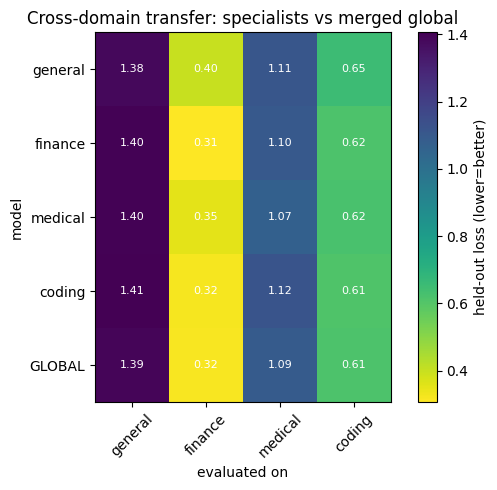

In [15]:
import matplotlib.pyplot as plt, numpy as np
doms = [c["domain"] for c in CLIENTS]; evalsets = [c["eval"] for c in CLIENTS]
rows = doms + ["GLOBAL"]; states = list(local_states) + [global_sd]
M = np.array([[evaluate(st, ev)[0] for ev in evalsets] for st in states])
set_global(global_sd)

plt.figure(figsize=(6, 5)); plt.imshow(M, cmap="viridis_r")
plt.colorbar(label="held-out loss (lower=better)")
plt.xticks(range(len(doms)), doms, rotation=45); plt.yticks(range(len(rows)), rows)
plt.xlabel("evaluated on"); plt.ylabel("model")
for i in range(len(rows)):
    for j in range(len(doms)):
        plt.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", color="white", fontsize=8)
plt.title("Cross-domain transfer: specialists vs merged global")
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/plot_transfer.png", dpi=130); plt.show()